# Полный пайплайн распознавания лиц

Собираем пайплайн из трёх независимых этапов:

- **Этап 1** - находит, где на фото лица (bounding box), используя готовый
  предобученный детектор.
- **Этап 2** - модель из **задания 1**: предсказывает 5 ключевых точек
  внутри каждого найденного лица и выравнивает его в канонический вид 112×112.
- **Этап 3** - модель из **задания 2**: превращает выровненное лицо в
  512-мерный эмбеддинг, обученный так, чтобы эмбеддинги одного человека были
  близки, а разных людей далеки друг от друга (ArcFace).



##  Импорты и настройки

In [1]:
import os, math
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms as T

device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print('device:', device)


device: mps


##  Этап 1: детектор лиц

**Выбор:** детектор лиц из библиотеки **InsightFace** (`FaceAnalysis`).

Почему именно он:

- Предобучен для **детекции лиц**, поэтому не требуется обучать собственный детектор.
- Показывает высокую точность обнаружения лиц даже при различных ракурсах, освещении и частичных перекрытиях.
- Работает на CPU и GPU. В данной работе используется `CPUExecutionProvider`, что позволяет запускать код без CUDA.


In [10]:
import insightface
import numpy as np
import cv2
from insightface.app import FaceAnalysis

app = FaceAnalysis(providers=['CPUExecutionProvider']) 
app.prepare(ctx_id=0, det_size=(640, 640))

def detect_face_boxes(image_rgb: np.ndarray, min_confidence: float = 0.90):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    faces = app.get(image_bgr)

    return np.array([face.bbox for face in faces], dtype=np.float32)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/vladzmitrovic/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/vladzmitrovic/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/vladzmitrovic/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/vladzmitrovic/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/vladzmitrovic/.insightface/models/buffalo_l/w600k_r50.onnx recognit

## Этап 2: ключевые точки и выравнивание (модель из задания 1)

Ниже - архитектура StackedHourglass и функция выравнивания
`similarity_transform` **в точности как в задании 1** 


In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)



class HourglassBlock(nn.Module):
    def __init__(self, channels, depth=4):
        super().__init__()
        self.depth = depth
        # Энкодер
        self.down = nn.ModuleList([
            ResidualBlock(channels, channels)
            for _ in range(depth)
        ])
        # Бутылочное горлышко
        self.bottom = ResidualBlock(channels, channels)
        self.upsample = nn.Upsample(scale_factor=2)

        # Декодер
        self.up = nn.ModuleList([
            ResidualBlock(channels, channels)
            for _ in range(depth)
        ])

    def forward(self, x):
        skips = []
        for i in range(self.depth):
            x = self.down[i](x)
            skips.append(x)
            x = nn.functional.max_pool2d(x, 2)
        x = self.bottom(x)
        for i in reversed(range(self.depth)):
            x = self.upsample(x)
            x = x + skips[i]
            x = self.up[i](x)

        return x

In [14]:
class StackedHourglass(nn.Module):

    def __init__(self, n_stacks: int = 2, n_feats: int = 128,
                 n_pts: int = 5, n_levels: int = 3):
        super().__init__()
        self.n_stacks = n_stacks


        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),  #64×64
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResidualBlock(64, 128),
            nn.MaxPool2d(2), #32×32
            ResidualBlock(128, n_feats),
        )

        # Hourglass-блоки
        self.hg_blocks = nn.ModuleList(
            [HourglassBlock(n_feats, n_levels) for _ in range(n_stacks)]
        )

        # после каждого HG  предсказание heatmap
        self.heads = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(n_feats, n_feats),
                nn.Conv2d(n_feats, n_pts, 1)
            )
            for _ in range(n_stacks)
        ])

        # Проекция для передачи информации 
        self.feat_proj = nn.ModuleList(
            [nn.Conv2d(n_feats, n_feats, 1) for _ in range(n_stacks - 1)]
        )
        self.pred_proj = nn.ModuleList(
            [nn.Conv2d(n_pts,   n_feats, 1) for _ in range(n_stacks - 1)]
        )

    def forward(self, x):
        x = self.stem(x)
        predictions = []

        for i, (hg, head) in enumerate(zip(self.hg_blocks, self.heads)):
            feat = hg(x)
            pred = head(feat)
            predictions.append(pred)

            # Передаём информацию 
            if i < self.n_stacks - 1:
                x = x + self.feat_proj[i](feat) + self.pred_proj[i](pred)

        return predictions  # список из тензоров 

In [15]:
def similarity_transform(src, dst):

    assert src.shape == dst.shape, 'src и dst должны быть одинаковой формы'
    n = src.shape[0]

    src = src.astype(np.float64)
    dst = dst.astype(np.float64)

    # центроиды и центрирование 
    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)
    src_c = src - src_mean  
    dst_c = dst - dst_mean

    # матрица взаимной ковариации 2x2
    # Sigma[i, j] показывает, насколько координата j исходных точек
    # коррелирует с координатой i целевых точек
    cov = (dst_c.T @ src_c) / n

    #SVD ковариационной матрицы 
    U, D, Vt = np.linalg.svd(cov)

    # защита от отражения
    if np.linalg.det(U @ Vt) < 0:
        U[:, -1] *= -1
        D[-1] *= -1

    #Шаг 5: оптимальный поворот
    R = U @ Vt

    #Шаг 6: оптимальный масштаб
    var_src = (src_c ** 2).sum() / n
    s = D.sum() / var_src

    #Шаг 7: оптимальный сдвиг
    t = dst_mean - s * (R @ src_mean)

    #Собираем в 2x3 матрицу для cv2.warpAffine
    M = np.zeros((2, 3), dtype=np.float64)
    M[:, :2] = s * R
    M[:, 2] = t
    return M.astype(np.float32)
    return M.astype(np.float32)


# Эталонные позиции 5 точек для канвы 112x112 (InsightFace / ArcFace стандарт)
ARCFACE_TEMPLATE_112 = np.array([
    [38.2946, 51.6963], [73.5318, 51.5014], [56.0252, 71.7366],
    [41.5493, 92.3655], [70.7299, 92.2041],
], dtype=np.float32)


def align_face(img_rgb: np.ndarray, landmarks_5: np.ndarray, out_size: int = 112) -> np.ndarray:
    dst = ARCFACE_TEMPLATE_112 * (out_size / 112.0)
    M = similarity_transform(landmarks_5.astype(np.float64), dst.astype(np.float64))
    return cv2.warpAffine(img_rgb, M, (out_size, out_size),
                          flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)


In [16]:
HG_IMG_SIZE = 128 
HG_HM_SIZE  = 32
CROP_PAD    = 0.15  

_IMAGENET_MEAN = (0.485, 0.456, 0.406)
_IMAGENET_STD  = (0.229, 0.224, 0.225)
_hg_norm = T.Normalize(_IMAGENET_MEAN, _IMAGENET_STD)

landmark_model = StackedHourglass(n_stacks=2, n_feats=128, n_pts=5, n_levels=3).to(device)

HOURGLASS_CKPT = '../models_weight/best_hourglass.pt'

)
landmark_model.load_state_dict(torch.load(HOURGLASS_CKPT, map_location=device))
landmark_model.eval()
print('Веса Hourglass загружены:', HOURGLASS_CKPT)


@torch.no_grad()
def hm_argmax(hm):
    K, H, W = hm.shape
    flat = hm.reshape(K, -1).argmax(-1)
    y = (flat // W).float()
    x = (flat %  W).float()
    return torch.stack([x, y], dim=-1).cpu().numpy()


@torch.no_grad()
def crop_and_align(image_rgb, box, out_size = 112):

    H, W = image_rgb.shape[:2]
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    pad = max(bw, bh) * CROP_PAD

    cx1 = int(max(0, x1 - pad)); cy1 = int(max(0, y1 - pad))
    cx2 = int(min(W, x2 + pad)); cy2 = int(min(H, y2 + pad))
    crop = image_rgb[cy1:cy2, cx1:cx2]
    ch, cw = crop.shape[:2]

    crop_rs = cv2.resize(crop, (HG_IMG_SIZE, HG_IMG_SIZE))
    crop_t  = _hg_norm(torch.from_numpy(crop_rs.astype(np.float32) / 255.).permute(2, 0, 1))
    crop_t  = crop_t.unsqueeze(0).to(device)

    pred_hm = landmark_model(crop_t)[-1].squeeze(0)          
    pts_hm  = hm_argmax(pred_hm)                             
    pts_crop = pts_hm * (HG_IMG_SIZE / HG_HM_SIZE)            

    # координаты точек - в исходном 
    pts_orig_crop = pts_crop * np.array([[cw / HG_IMG_SIZE, ch / HG_IMG_SIZE]])
    aligned = align_face(crop, pts_orig_crop, out_size=out_size)

    return crop_rs, pts_crop, aligned


Веса Hourglass загружены: ../models_weight/best_hourglass.pt


## Этап 3: эмбеддинг лица (модель из задания 2)

Backbone `fficientNet-B0 + neck` - та же архитектура, что обучалась в задании 2 с
ArcFace-головой. Саму ArcFace-голову (`ArcMarginHead`) для инференса **не
используем** - она нужна была только во время обучения, чтобы давить на
backbone угловым отступом. Для получения эмбеддинга достаточно backbone.


In [20]:
ckpt = torch.load('../models_weight/arcface_best.pt', map_location=device)

print(type(ckpt))
print(ckpt.keys())

<class 'dict'>
dict_keys(['backbone', 'head'])


In [22]:
EMB_DIM = 512

import torch.nn as nn
from torchvision import models

EMB_DIM = 512 # длина вектора признаков


class FaceBackbone(nn.Module):

    def __init__(self, emb_dim=EMB_DIM, pretrained=True, dropout=0.3):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        net = models.efficientnet_b0(weights=weights)

        in_features = net.classifier[1].in_features
        net.classifier = nn.Identity()
        self.net = net

        self.neck = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, emb_dim),
            nn.BatchNorm1d(emb_dim),
        )

    def forward(self, x):
        return self.neck(self.net(x))


embed_model = FaceBackbone(emb_dim=EMB_DIM, pretrained=False).to(device)

ARCFACE_CKPT = '../models_weight/arcface_best.pt'

ckpt = torch.load(ARCFACE_CKPT, map_location=device)
embed_model.load_state_dict(ckpt['backbone'])  
embed_model.eval()
print('Веса эмбеддинг - модели загружены:', ARCFACE_CKPT)


@torch.no_grad()
def get_embedding(aligned_face_rgb: np.ndarray) -> np.ndarray:
    """
    Считает L2-нормированный эмбеддинг для одного выровненного лица 112x112.
    """
    face_t = _hg_norm(torch.from_numpy(aligned_face_rgb.astype(np.float32) / 255.).permute(2, 0, 1))
    face_t = face_t.unsqueeze(0).to(device)
    emb = embed_model(face_t)
    emb = F.normalize(emb, dim=1)
    return emb.squeeze(0).cpu().numpy()


Веса эмбеддинг - модели загружены: ../models_weight/arcface_best.pt


## Полный пайплайн

In [23]:
def run_face_pipeline(image_path: str, min_confidence: float = 0.70):

    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    boxes = detect_face_boxes(image_rgb, min_confidence=min_confidence)

    results = []
    for box in boxes:
        crop_rs, pts_crop, aligned = crop_and_align(image_rgb, box)
        embedding = get_embedding(aligned)
        results.append({
            'box': box,
            'crop': crop_rs,
            'points': pts_crop,
            'aligned': aligned,
            'embedding': embedding,
        })
    return image_rgb, results


### Метрики расстояния между эмбеддингами

Так как эмбеддинги L2-нормированы (лежат на единичной сфере), для сравнения
двух лиц удобны обе стандартные метрики:

- **Косинусное сходство** $\cos = e_1 \cdot e_2 \in [-1, 1]$ — чем ближе к 1,
  тем более похожи лица. Именно эту величину напрямую оптимизировал ArcFace.
- **Косинусное расстояние** $d_{cos} = 1 - \cos \in [0, 2]$ — чем меньше, тем
  более похожи лица.



In [24]:
def embedding_distance(emb1, emb2):
    cos_sim = float(np.dot(emb1, emb2))
    return {
        'cosine_similarity': cos_sim,
        'cosine_distance':   1.0 - cos_sim,
    }


## Демонстрация: одинаковые и разные люди

Берём по 2 фотографии одного и того же человека и 2 фотографии разных людей
из исходного датасета CelebA (`identity_CelebA.txt` + оригинальные
 изображения - то есть **не** предобработанные заранее, как это
и должно быть при использовании полного пайплайна .


In [49]:
DATA_ROOT = '../annotation/'  
IMG_DIR   = '../img_celeba'

df_identity = pd.read_csv(f'{DATA_ROOT}/identity_CelebA.txt', sep=r'\s+',
                          header=None, names=['image_id', 'person_id'])

def wild_image_path(image_id: str):

    return os.path.join(IMG_DIR, image_id)


# один и тот же человек
same_person_photos = df_identity.groupby('person_id').filter(lambda g: len(g) >= 2)
some_person_id = same_person_photos['person_id'].iloc[6000]
same_pair_ids = same_person_photos[same_person_photos['person_id'] == some_person_id]['image_id'].iloc[:2].tolist()

# два разных человека
other_person_id = same_person_photos['person_id'].iloc[301]
diff_pair_ids = [
    same_person_photos[same_person_photos['person_id'] == some_person_id]['image_id'].iloc[0],
    same_person_photos[same_person_photos['person_id'] == other_person_id]['image_id'].iloc[0],
]

print('Пара "один и тот же человек":', same_pair_ids, ' (person_id =', some_person_id, ')')
print('Пара "разные люди":          ', diff_pair_ids)


Пара "один и тот же человек": ['006004.jpg', '009305.jpg']  (person_id = 6152 )
Пара "разные люди":           ['006004.jpg', '000302.jpg']


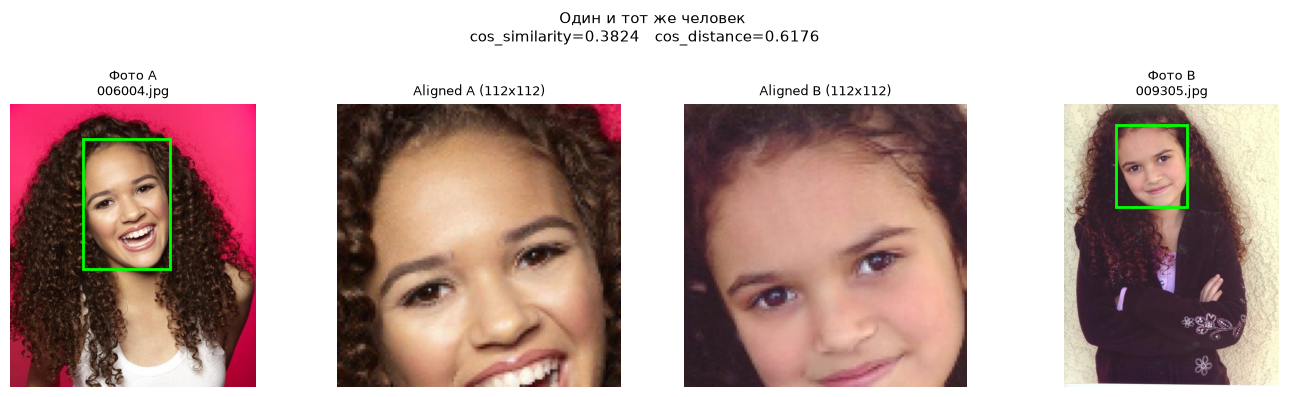

In [50]:
import cv2
def show_pair_result(img_id_a: str, img_id_b: str, title: str):
    """Прогоняет пару изображений через весь пайплайн и показывает результат."""
    path_a = wild_image_path(img_id_a)
    path_b = wild_image_path(img_id_b)

    img_a, res_a = run_face_pipeline(path_a)
    img_b, res_b = run_face_pipeline(path_b)

    assert len(res_a) > 0 and len(res_b) > 0, 'Лицо не найдено на одной из фотографий'

    # берём первое (самое уверенное) найденное лицо на каждом фото
    face_a, face_b = res_a[0], res_b[0]
    dist = embedding_distance(face_a['embedding'], face_b['embedding'])

    fig, axes = plt.subplots(1, 4, figsize=(14, 4))

    axes[0].imshow(img_a); axes[0].set_title(f'Фото A\n{img_id_a}', fontsize=9)
    x1, y1, x2, y2 = face_a['box']
    axes[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='lime', linewidth=2))
    axes[0].axis('off')

    axes[1].imshow(face_a['aligned']); axes[1].set_title('Aligned A (112x112)', fontsize=9); axes[1].axis('off')

    axes[2].imshow(face_b['aligned']); axes[2].set_title('Aligned B (112x112)', fontsize=9); axes[2].axis('off')

    axes[3].imshow(img_b); axes[3].set_title(f'Фото B\n{img_id_b}', fontsize=9)
    x1, y1, x2, y2 = face_b['box']
    axes[3].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='lime', linewidth=2))
    axes[3].axis('off')

    plt.suptitle(
        f'{title}\n'
        f'cos_similarity={dist["cosine_similarity"]:.4f}   '
        f'cos_distance={dist["cosine_distance"]:.4f}   ',
        fontsize=11
    )
    plt.tight_layout(); plt.show()
    return dist


dist_same = show_pair_result(same_pair_ids[0], same_pair_ids[1], 'Один и тот же человек')


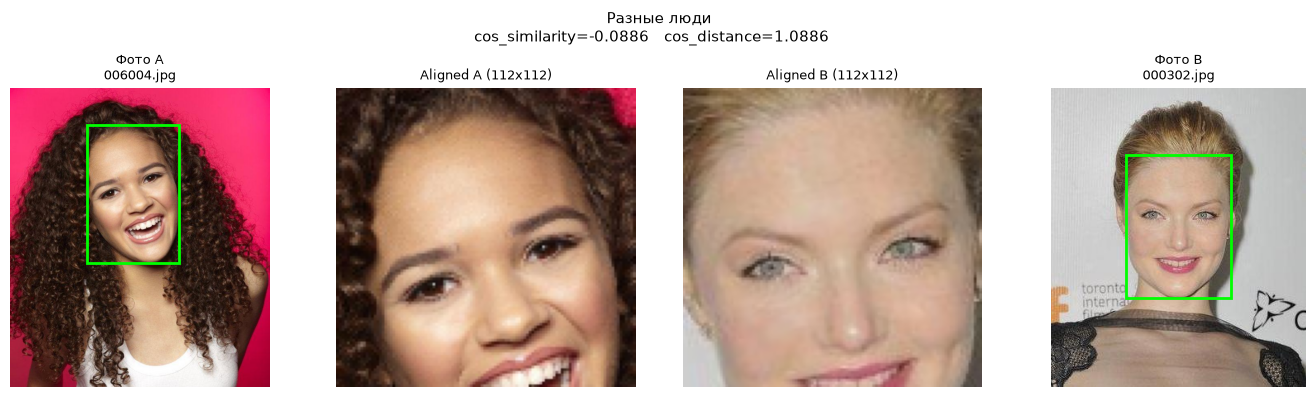

In [51]:
dist_diff = show_pair_result(diff_pair_ids[0], diff_pair_ids[1], 'Разные люди')


У одинаковых людей **cos_similarity** значительно выше, а **соs_distanse** меньше.


## Демонстрация на фото с несколькими лицами

CelebA - датасет портретов (одно лицо на фото), поэтому здесь нет готового
группового снимка.

Чтобы продемонстрировать это, подставил путь к групповому фото с интернета
(`GROUP_PHOTO_PATH`), и ниже будет посчитана матрица попарных расстояний
между всеми найденными лицами.


Найдено лиц: 16


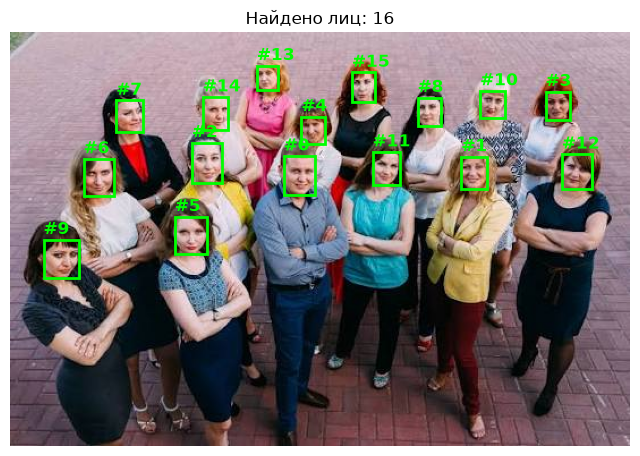

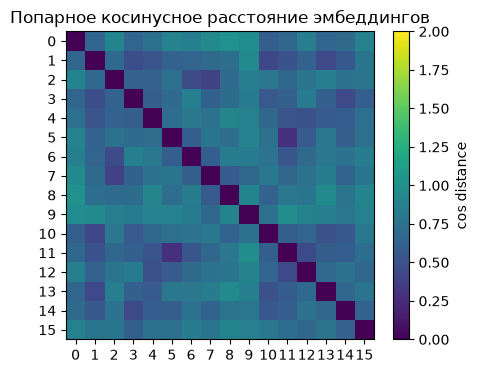

In [54]:
GROUP_PHOTO_PATH = '../group_photo/images.png'   

if Path(GROUP_PHOTO_PATH).exists():
    img_group, faces_group = run_face_pipeline(GROUP_PHOTO_PATH)
    print(f'Найдено лиц: {len(faces_group)}')

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img_group)
    for i, face in enumerate(faces_group):
        x1, y1, x2, y2 = face['box']
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, edgecolor='lime', linewidth=2))
        ax.text(x1, y1 - 5, f'#{i}', color='lime', fontsize=12, fontweight='bold')
    ax.axis('off'); ax.set_title(f'Найдено лиц: {len(faces_group)}')
    plt.show()

    # Матрица попарных косинусных расстояний между всеми найденными лицами
    n = len(faces_group)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            # Cosine Distance = 1 - Cosine Similarity
            dist_matrix[i, j] = 1.0 - np.dot(faces_group[i]['embedding'], faces_group[j]['embedding'])

    plt.figure(figsize=(5, 4))
    plt.imshow(dist_matrix, cmap='viridis', vmin=0, vmax=2)
    plt.colorbar(label='cos distance')
    plt.xticks(range(n)); plt.yticks(range(n))
    plt.title('Попарное косинусное расстояние эмбеддингов')
    plt.show()
else:
    print(f'Файл {GROUP_PHOTO_PATH} не найден - подставьте свой путь к групповому фото, '
          f'чтобы увидеть работу пайплайна сразу на нескольких лицах.')

## Итог


**Метрика сравнения:** косинусное сходство / косинусное расстояние. Пара фото одного
человека даёт заметно более высокое косинусное сходство (меньшее расстояние),
чем пара фото разных людей - это и есть рабочая проверка, что весь пайплайн собран верно.
